# ARTI 403 – Image Processing
## Lab 2 – Digital Image Fundamentals
## Student name : Mujtaba Alnuwaysir
## ID : 2240007941
## 7MA2


## Libraries
Run the installation line only if a package is missing.

In [1]:
# %pip install numpy matplotlib pillow opencv-python
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
print('Libraries imported successfully')

Libraries imported successfully


## Image files
The lab requires these exact filenames: `lena_gray_256.tif`, `cameraman.tif`, `A.png`, and `B.png`.
Place them in an `images` folder next to this notebook.

In [2]:
IMAGE_DIR = 'images'
os.makedirs(IMAGE_DIR, exist_ok=True)

required_images = ['lena_gray_256.tif', 'cameraman.tif', 'A.png', 'B.png']
missing = [f for f in required_images if not os.path.isfile(os.path.join(IMAGE_DIR, f))]

if missing:
    print('Missing required image files:')
    for f in missing:
        print(' -', f)
    print('\nPut the four lab images inside the images folder, then run this cell again.')
else:
    print('All four required images are available.')

All four required images are available.


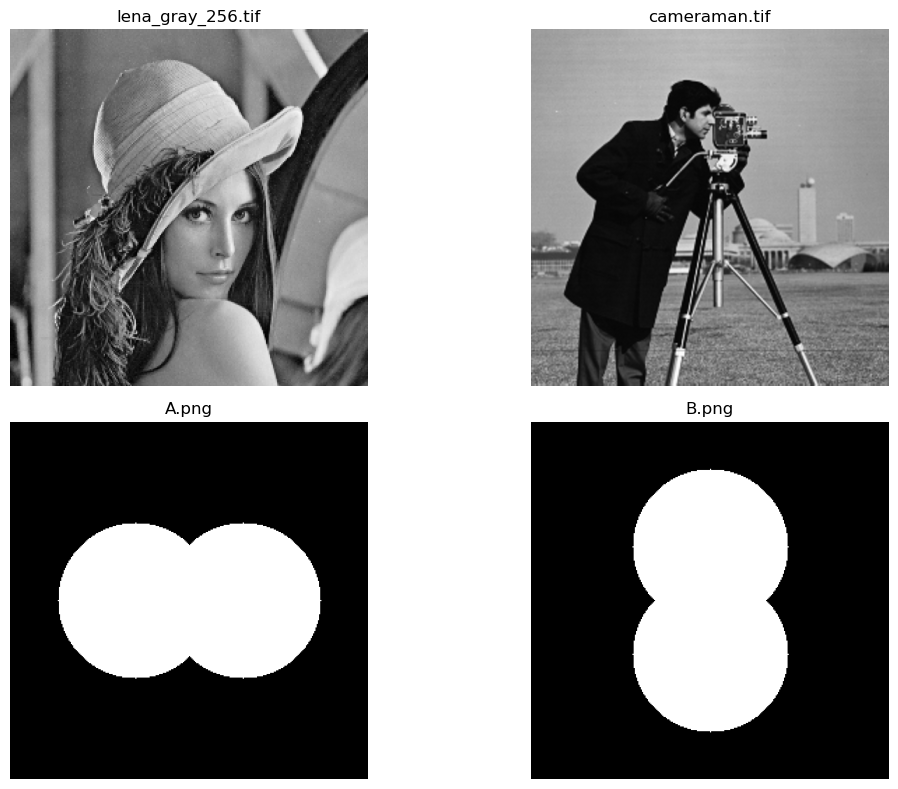

In [20]:
image_folder = "images"

image_names = [
    "lena_gray_256.tif",
    "cameraman.tif",
    "A.png",
    "B.png"
]

plt.figure(figsize=(12, 8))

for i, name in enumerate(image_names):
    path = os.path.join(image_folder, name)
    
    image = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    
    if image is None:
        print(f" Image not found❌ {path}")
        continue
    
    plt.subplot(2, 2, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(name)
    plt.axis("off")

plt.tight_layout()
plt.show()

# Task 1 – Image Sampling and Quantization

In [21]:
# Load lena_gray_256.tif
image_path = os.path.join(IMAGE_DIR, 'lena_gray_256.tif')
original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if original_image is None:
    raise FileNotFoundError(f'Could not load {image_path}. Check the images folder.')

print('Image loaded successfully')
print('Image shape:', original_image.shape)

Image loaded successfully
Image shape: (256, 256)


In [22]:
# Sampling function
def sample_image(image, factor):
    height, width = image.shape[:2]
    return cv2.resize(image, (width // factor, height // factor), interpolation=cv2.INTER_NEAREST)

# Quantization function
def quantize_image(image, levels):
    step = 256 // levels
    quantized_image = np.floor(image / step) * step
    return quantized_image.astype(np.uint8)

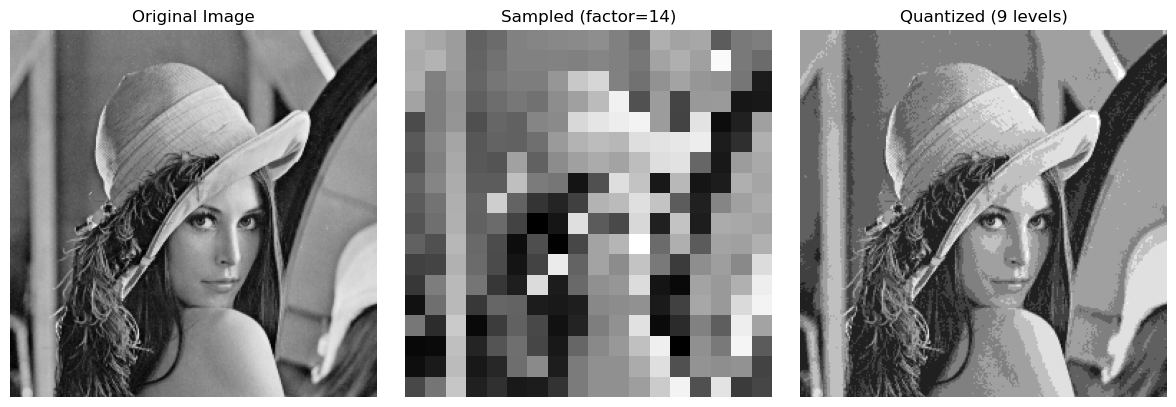

In [23]:
# Parameters specified in the lab
sampling_factor = 14
quantization_levels = 9

sampled_image = sample_image(original_image, sampling_factor)
quantized_image = quantize_image(original_image, quantization_levels)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(original_image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(sampled_image, cmap='gray')
plt.title(f'Sampled (factor={sampling_factor})')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(quantized_image, cmap='gray')
plt.title(f'Quantized ({quantization_levels} levels)')
plt.axis('off')
plt.tight_layout()
plt.show()

## Task 1 – Change the Sampling and Quantization Parameters

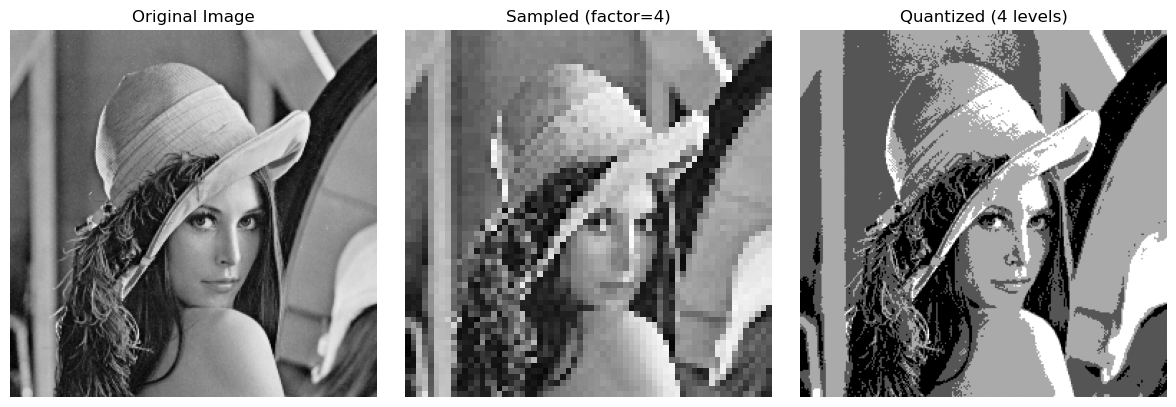

In [24]:
# Change the parameters as required by the lab exercise
sampling_factor = 4
quantization_levels = 4

sampled_image_2 = sample_image(original_image, sampling_factor)
quantized_image_2 = quantize_image(original_image, quantization_levels)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(original_image, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(sampled_image_2, cmap='gray')
plt.title(f'Sampled (factor={sampling_factor})')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(quantized_image_2, cmap='gray')
plt.title(f'Quantized ({quantization_levels} levels)')
plt.axis('off')
plt.tight_layout()
plt.show()

# Task 2 – Arithmetic Operations

In [25]:
# Load lena and cameraman and resize both to 400 x 400
img1 = Image.open(os.path.join(IMAGE_DIR, 'lena_gray_256.tif')).convert('L')
img2 = Image.open(os.path.join(IMAGE_DIR, 'cameraman.tif')).convert('L')

resize = (400, 400)
img1 = img1.resize(resize, Image.Resampling.LANCZOS)
img2 = img2.resize(resize, Image.Resampling.LANCZOS)

im1arr = np.asarray(img1, dtype=np.uint8)
im2arr = np.asarray(img2, dtype=np.uint8)

print('Lena shape:', im1arr.shape)
print('Cameraman shape:', im2arr.shape)

Lena shape: (400, 400)
Cameraman shape: (400, 400)


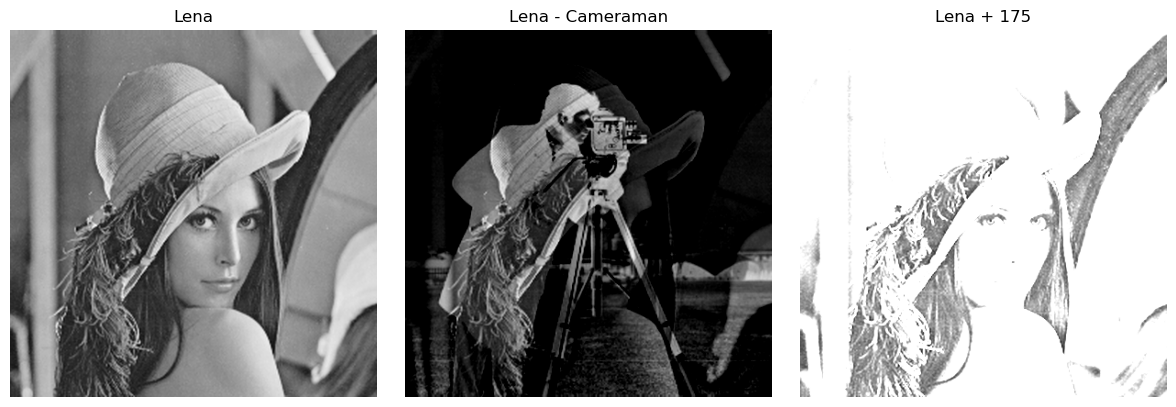

In [26]:
# Subtraction
subtracted = cv2.subtract(im1arr, im2arr)

# Add constant 175
added_constant = cv2.add(im1arr, 175)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(im1arr, cmap='gray')
plt.title('Lena')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(subtracted, cmap='gray')
plt.title('Lena - Cameraman')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(added_constant, cmap='gray')
plt.title('Lena + 175')
plt.axis('off')
plt.tight_layout()
plt.show()

# Task 2 – Sets / Logical Operations

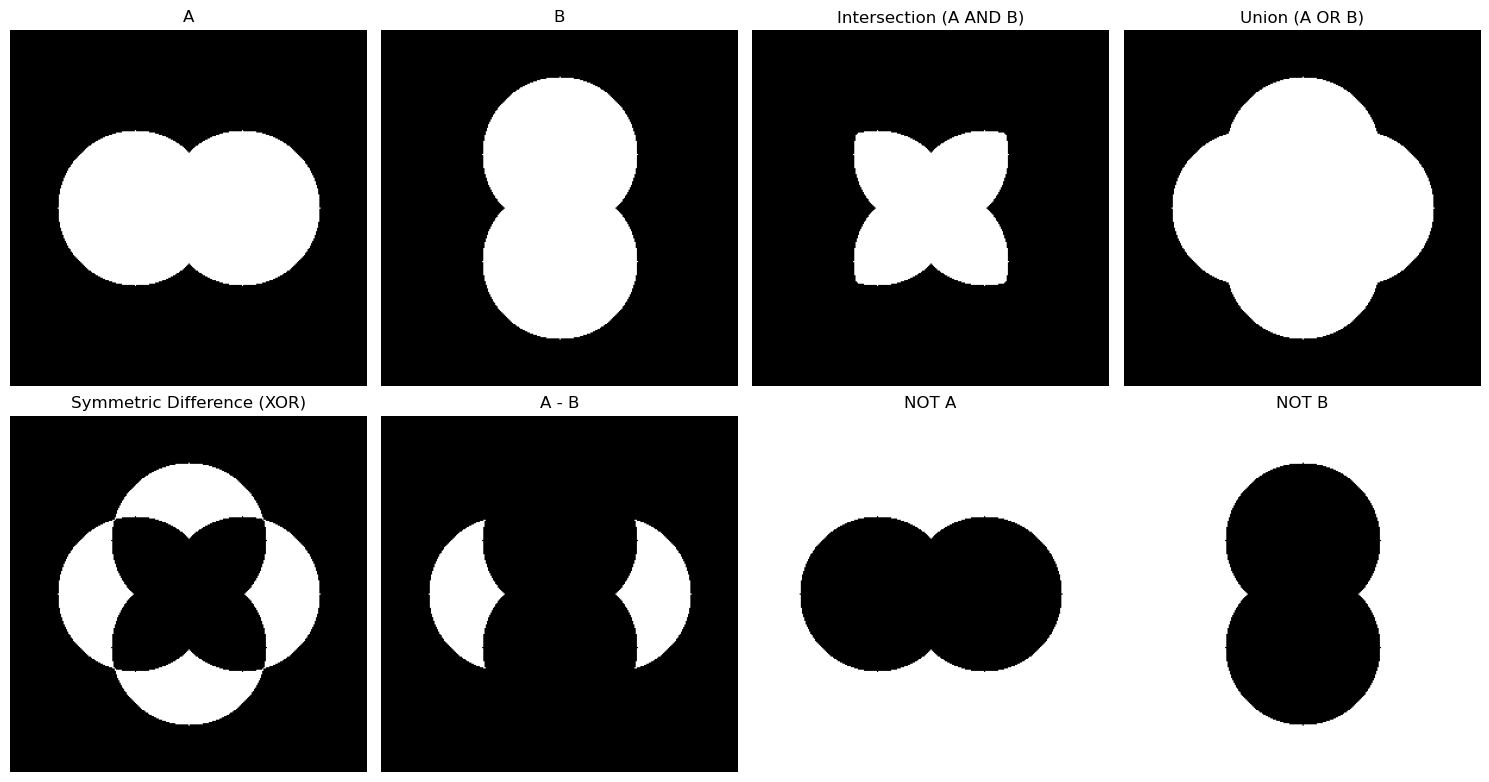

In [27]:
# Load A.png and B.png
A = cv2.imread(os.path.join(IMAGE_DIR, 'A.png'), cv2.IMREAD_GRAYSCALE)
B = cv2.imread(os.path.join(IMAGE_DIR, 'B.png'), cv2.IMREAD_GRAYSCALE)

if A is None or B is None:
    raise FileNotFoundError('A.png and/or B.png are missing from the images folder.')

# Make the two images the same size for pixel-wise operations
B = cv2.resize(B, (A.shape[1], A.shape[0]), interpolation=cv2.INTER_NEAREST)

# Logical/set operations
intersection = cv2.bitwise_and(A, B)
union = cv2.bitwise_or(A, B)
symmetric_difference = cv2.bitwise_xor(A, B)
not_A = cv2.bitwise_not(A)
not_B = cv2.bitwise_not(B)
difference_A_minus_B = cv2.bitwise_and(A, cv2.bitwise_not(B))

plt.figure(figsize=(15, 8))
results = [
    ('A', A), ('B', B), ('Intersection (A AND B)', intersection),
    ('Union (A OR B)', union), ('Symmetric Difference (XOR)', symmetric_difference),
    ('A - B', difference_A_minus_B), ('NOT A', not_A), ('NOT B', not_B)
]
for i, (title, img) in enumerate(results, 1):
    plt.subplot(2, 4, i)
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
plt.tight_layout()
plt.show()